In [1]:
import json
import math
from collections import Counter
from augur.utils import json_to_tree
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import pandas as pd
import numpy as np

In [2]:
# read in adaptive muts
adaptive_mut_file = f"../egg-mutation-analysis/egg-adaptive-muts/ha_HA1_adaptive-muts.json"

with open(adaptive_mut_file) as json_handle:
    egg_muts_info = json.load(json_handle)

adaptive_muts_by_virus = {}

for v in ['h3n2', 'h1n1pdm', 'vic', 'yam']:
    ha1_adaptive_muts= egg_muts_info['aas_at_adaptive_sites'][v]
    adaptive_muts_by_virus[v] = {int(k):v for k,v in ha1_adaptive_muts.items()}

In [3]:
def get_strain_year(virus):
    """
    Return the year for all egg-passaged strains    
    """
    
    tree_path= f'../nextstrain_builds/egg-enriched/auspice/{virus}_ha_egg.json'
    
    #read in the tree
    with open(tree_path, 'r') as f:
        tree_json = json.load(f)
        
    #put tree in Bio.phylo format
    tree = json_to_tree(tree_json)
    
    eggstrains_to_year = {}
    
    for node in tree.find_clades(terminal=True):
        passage = node.node_attrs['passage_category']['value']
        date = node.node_attrs['num_date']['value']
        year = math.trunc(date)
        if passage == 'egg':
            eggstrains_to_year[node.name] = year

            
    return eggstrains_to_year

In [4]:
def get_num_adaptive_muts_per_year(virus):
    """
    Find the number of different adaptive muts observed per year
    """
    # get year for each egg strain
    eggstrains_to_year = get_strain_year(virus)
    
    # get muts for each egg strain
    curated_mut_file = f"../egg-mutation-analysis/egg-muts-by-strain/{virus}_ha_curated-egg-muts.json"
    
    with open(curated_mut_file) as json_handle:
        egg_mut_info = json.load(json_handle)
    
    # get range of  years with egg strains
    max_year = max(eggstrains_to_year.values())
    min_year = min(eggstrains_to_year.values())
    
    # all adaptive muts observed each year
    adaptive_muts_by_year = {x:[] for x in range(min_year, max_year+1)}
    
    # also keep track of total number of egg strains in year
    total_egg_strains_by_year = {x:0 for x in range(min_year, max_year+1)}
    # and num of egg strains with an adaptive mut
    adapted_egg_strains_by_year = {x:0 for x in range(min_year, max_year+1)}
    

    for strain, muts in egg_mut_info.items():
        year = eggstrains_to_year[strain]
        # increase count of egg strains in this year
        total_egg_strains_by_year[year]+=1
        
        # find what muts this strain has
        has_mut = False
        for g, m_list in muts.items():
            if g=='HA1':
                for m in m_list:
                    m_pos = int(m[:-1])
                    # if this is an adaptive mut, add it to the yearly tracker
                    if m_pos in adaptive_muts_by_virus[virus].keys():
                        if m[-1] in adaptive_muts_by_virus[virus][m_pos]:
                            adaptive_muts_by_year[year].append(m)
                            # now we've seen an adaptive mut
                            has_mut = True
        # if this strain had an adaptive mut, add to the yearly count
        if has_mut == True:
            adapted_egg_strains_by_year[year]+=1
    
    
    
    return adaptive_muts_by_year, total_egg_strains_by_year, adapted_egg_strains_by_year

In [5]:
def counts_in_sliding_windows(virus, window_len):
    """
    Get the number of adaptive muts observed in each window
    Same for proportion of egg strains mut
    """
    
    adaptive_muts_by_year, total_egg_strains_by_year, adapted_egg_strains_by_year = get_num_adaptive_muts_per_year(virus)
    # get time range
    all_years = list(adaptive_muts_by_year.keys())
    windows = [all_years[i:i + window_len] for i in range(len(all_years) - window_len + 1)]
    
    # get proportion of egg strains mutated in window
    proportion_adapted_by_window = {}
    # the total number of strains in window store by window midpoint
    counts_per_window = {}
    for w in windows:
        w_total = 0
        adapted_total = 0
        for y in w:
            w_total+=total_egg_strains_by_year[y]
            adapted_total+=adapted_egg_strains_by_year[y]

        window_midpoint = (w[-1] + w[0])/2
        # if there are any egg strains in this window
        if w_total!=0:
            proportion_adapted_by_window[window_midpoint] = adapted_total/w_total
            counts_per_window[window_midpoint] = w_total
            
    
    # aggregate adaptive muts in window
    # store by window midpoint
    adaptve_muts_by_window = {}
    adaptive_sites_by_window = {}
    prevalent_adaptive_sites_by_window = {}
    for w in windows:
        adaptive_muts_in_w = []
        adaptive_sites_in_w = []
        for y in w:
            adaptive_muts_in_w+=adaptive_muts_by_year[y]
            adaptive_sites_in_w+=[x[:-1] for x in adaptive_muts_by_year[y]]
            
        window_midpoint = (w[-1] + w[0])/2
        adaptve_muts_by_window[window_midpoint] = adaptive_muts_in_w
        adaptive_sites_by_window[window_midpoint] = adaptive_sites_in_w
        # and only those that are mutated in the window at least twice times, or in at least 7.5% of strains
        prevalent_adaptive_sites_by_window[window_midpoint] = [x for x in adaptive_sites_in_w 
                                                               if adaptive_sites_in_w.count(x)>=2 
                                                               or adaptive_sites_in_w.count(x)/counts_per_window[window_midpoint] >=0.075]
        
    
    # now count how many of the adaptive muts were observed each window
    count_adaptive_muts_by_window = {y:len(set(ms)) for y, ms in adaptve_muts_by_window.items()}
    
    # also do this by residue, instead of exact mut
    count_adaptive_sites_by_window = {y:len(set([int(m[:-1]) for m in ms])) for y, ms in adaptve_muts_by_window.items()}
    
    # only count site if it is mutated at least 3 times in window
    count_prevalent_adaptive_sites_by_window = {y:len(set([int(m[:-1]) for m in ms])) for y, ms in prevalent_adaptive_sites_by_window.items()}
        
    
    return count_adaptive_muts_by_window, count_adaptive_sites_by_window, count_prevalent_adaptive_sites_by_window, proportion_adapted_by_window

In [6]:
virus_cmap = {'B/Yam': '#fbba0a', 'B/Vic': '#FF4500', 'A/H3N2': '#6C3BAA', 'A/H1N1pdm': '#45b6fe'}


In [7]:
def plot_adaptive_sites_by_year(window_len, ax):
    """
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    viruses = ['h3n2', 'h1n1pdm', 'vic', 'yam']
    prettify_names = {'h3n2': 'A/H3N2', 'h1n1pdm': 'A/H1N1pdm', 'vic': 'B/Vic', 'yam': 'B/Yam'}
    
    data_to_plot = []
    for v in viruses:
        (count_adaptive_muts_by_window, count_adaptive_sites_by_window, 
        count_prevalent_adaptive_sites_by_window, proportion_adapted_by_window) = counts_in_sliding_windows(v, window_len)
        for y, c in count_adaptive_sites_by_window.items():
            data_to_plot.append({'virus': prettify_names[v], 'year': y, 'count': c})
    
    df = pd.DataFrame(data_to_plot)
        
    sns.lineplot(x='year', y='count', hue='virus', data=df, palette=virus_cmap, legend=False, ax=ax)
    sns.scatterplot(x='year', y='count', hue='virus', data=df, palette=virus_cmap, ax=ax)
    
    ax.set_ylim(bottom=0)
    
    
    ax.set_ylabel('Number of adaptive\nsites observed')
    ax.set_xlabel('')
    
    legend = ax.legend(title=None, fontsize=8)
    sns.despine()
    
    return ax


In [8]:
def plot_proportion_adapted_by_year(window_len, ax):
    """
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    viruses = ['h3n2', 'h1n1pdm', 'vic', 'yam']
    prettify_names = {'h3n2': 'A/H3N2', 'h1n1pdm': 'A/H1N1pdm', 'vic': 'B/Vic', 'yam': 'B/Yam'}
    
    data_to_plot = []
    for v in viruses:
        (count_adaptive_muts_by_window, count_adaptive_sites_by_window, 
         count_prevalent_adaptive_sites_by_window, proportion_adapted_by_window) = counts_in_sliding_windows(v, window_len)
        for y, p in proportion_adapted_by_window.items():
            data_to_plot.append({'virus': prettify_names[v], 'year': y, 'proportion': p})
    
    df = pd.DataFrame(data_to_plot)
        
    sns.lineplot(x='year', y='proportion', hue='virus', data=df, palette=virus_cmap, legend=False, ax=ax)
    sns.scatterplot(x='year', y='proportion', hue='virus', data=df, palette=virus_cmap, legend=False, ax=ax)
    
    
    ax.set_ylabel('Proportion of egg strains\nwith adaptive mut')
    ax.set_xlabel('')
        
    sns.despine()
    
    return ax

In [10]:
def plot_overall_supp(window_len, filename=None):
    """
    Plot overall stats over time:
    1. number of egg-adaptive sites observed
    2. proportion of egg-passaged strains that get adaptive mut
    """
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(5,6), sharex=True)
    
    ax1.text(-0.15, 0.98, 'A', fontsize=16, transform=ax1.transAxes)
    plot_adaptive_sites_by_year(window_len, ax1)
    
    ax2.text(-0.15, 0.98, 'B', fontsize=16, transform=ax2.transAxes)
    plot_proportion_adapted_by_year(window_len, ax2)

    
    if filename:
        fig.savefig(filename, dpi=400, bbox_inches='tight', transparent=False, facecolor='white')
    

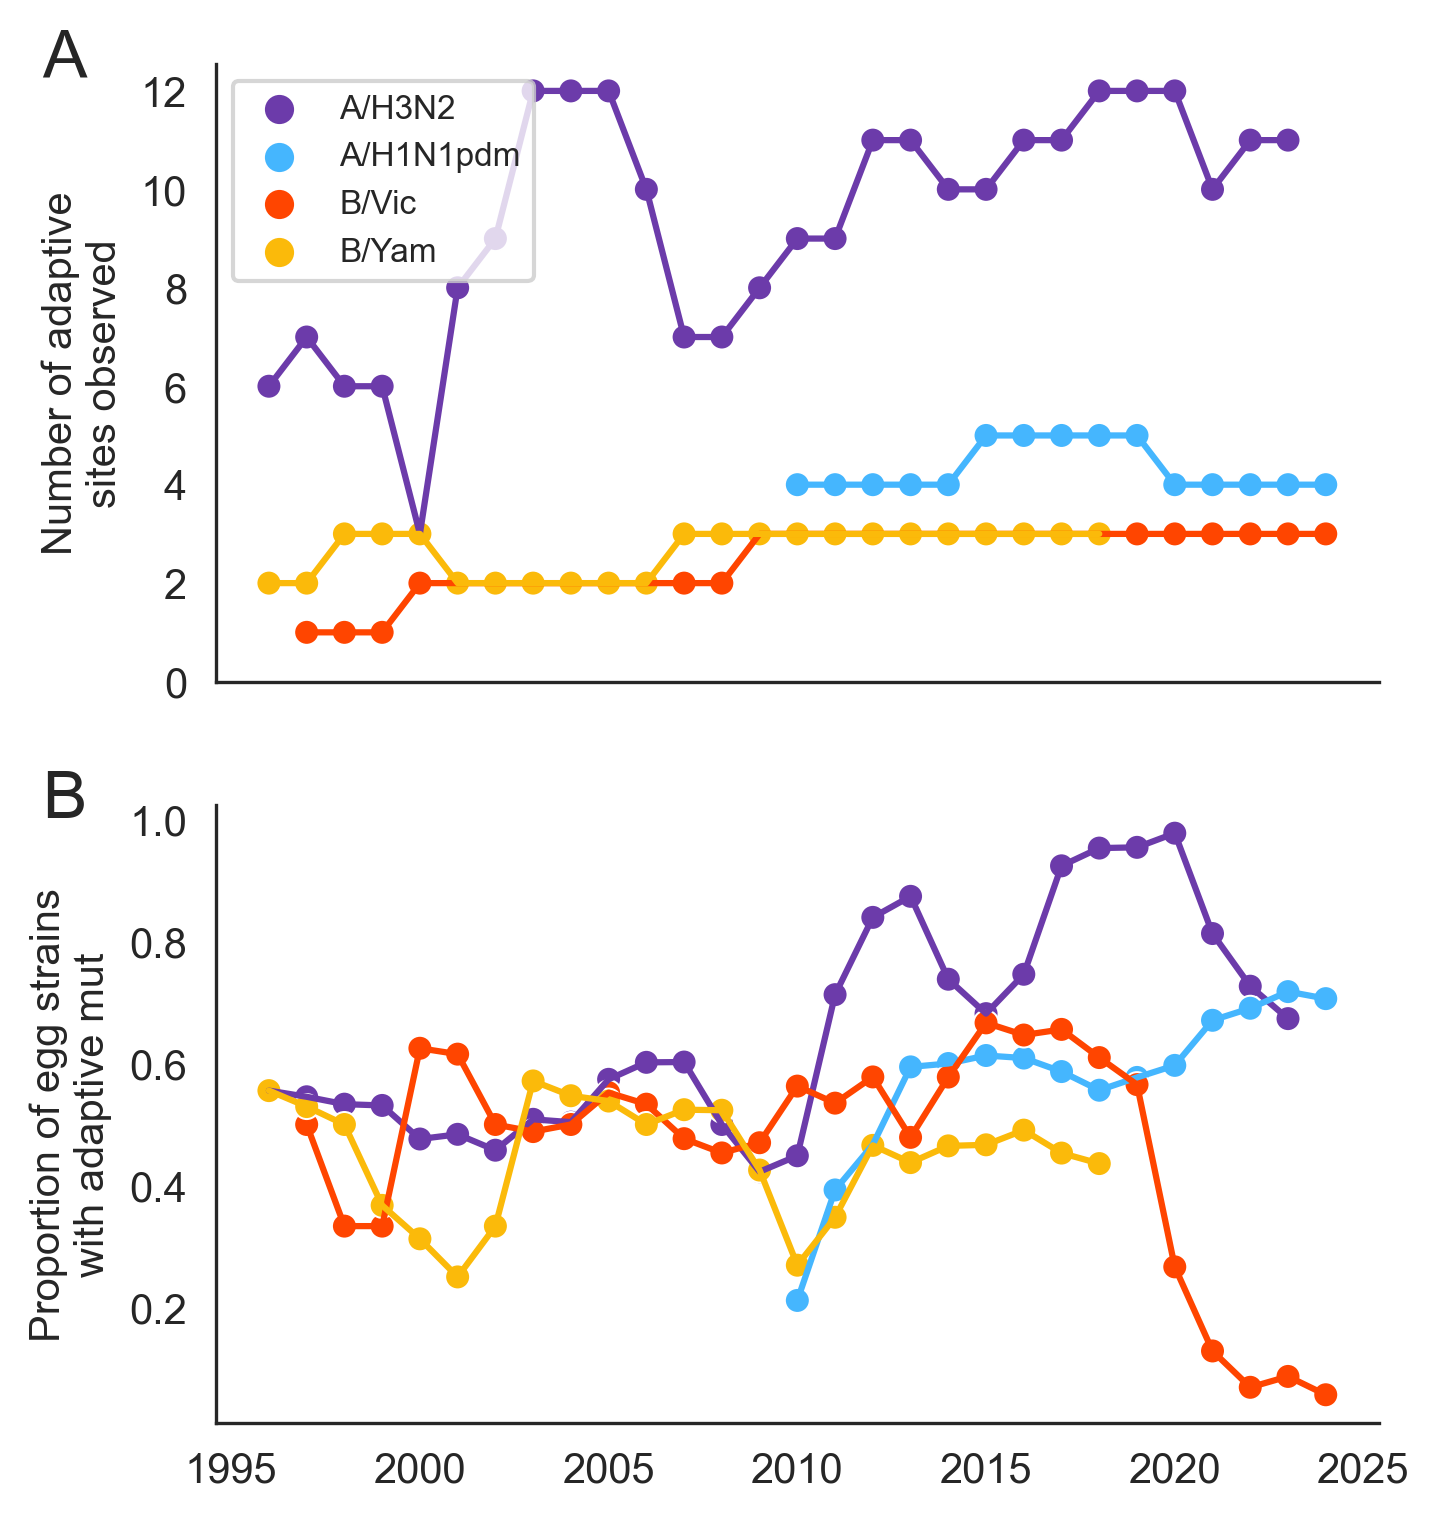

In [12]:
plot_overall_supp(3, filename='Supplement-totalMutsOverTime/Supp_totalMutsOverTime.png')